# Climate Data Analysis: Histograms and Time Series

This notebook analyzes climate data from multiple sources:
- NOAA Daily Weather Data
- NOAA Weekly Weather Data
- CO2 Mole Fraction Weekly Data (Mauna Loa Observatory)

For each feature, we provide:
1. Histogram distribution
2. Time series plot
3. Denoised time series using convolution (where applicable)

## Imports

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.signal import savgol_filter

warnings.filterwarnings('ignore')

## Settings

In [2]:
# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
FIGSIZE_HIST = (12, 5)
FIGSIZE_TS = (15, 5)
FIGSIZE_COMBINED = (15, 8)

# Convolution settings
WINDOW_SIZE = 30
GAUSSIAN_SIGMA = 5
SAVGOL_WINDOW = 51
SAVGOL_POLYORDER = 3

# Data paths
PATH_NOAA_DAILY = DATA_DRI / '../data/climate/noaa_daily.csv'
PATH_NOAA_WEEKLY = '../data/climate/noaa_weekly.csv'
PATH_CO2_WEEKLY = '../data/climate/co2_weekly_mlo.csv'
PATH_SPI_WEEKLY = '../data/climate/spi_weekly_multiscale.csv'
PATH_PALMER = '../data/climate/palmer'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Helper Functions

In [3]:
def plot_histogram(data, feature, title, bins=50, color='steelblue'):
    fig, ax = plt.subplots(figsize=FIGSIZE_HIST)
    clean_data = data.dropna()
    ax.hist(clean_data, bins=bins, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    stats_text = f'Mean: {clean_data.mean():.2f}\nStd: {clean_data.std():.2f}\nCount: {len(clean_data):,}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_time_series(dates, data, feature, title, color='steelblue'):
    fig, ax = plt.subplots(figsize=FIGSIZE_TS)
    ax.plot(dates, data, color=color, alpha=0.7, linewidth=0.8)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(feature, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_time_series_with_denoising(dates, data, feature, title, color='steelblue'):
    mask = ~np.isnan(data)
    clean_data = data[mask]
    clean_dates = dates[mask]
    if len(clean_data) < SAVGOL_WINDOW:
        print(f"Not enough data points for denoising ({len(clean_data)} < {SAVGOL_WINDOW})")
        return
    moving_avg = uniform_filter1d(clean_data, size=WINDOW_SIZE, mode='nearest')
    gaussian = gaussian_filter1d(clean_data, sigma=GAUSSIAN_SIGMA, mode='nearest')
    savgol = savgol_filter(clean_data, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_POLYORDER, mode='nearest')
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_COMBINED)
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes[0, 0].plot(clean_dates, clean_data, color=color, alpha=0.5, linewidth=0.8)
    axes[0, 0].set_title('Original Data', fontsize=12)
    axes[0, 0].set_ylabel(feature, fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 1].plot(clean_dates, clean_data, color=color, alpha=0.3, linewidth=0.5)
    axes[0, 1].plot(clean_dates, moving_avg, color='red', linewidth=1.5, label=f'Moving Avg (w={WINDOW_SIZE})')
    axes[0, 1].set_title('Moving Average Filter', fontsize=12)
    axes[0, 1].set_ylabel(feature, fontsize=10)
    axes[0, 1].legend(loc='best', fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[1, 0].plot(clean_dates, clean_data, color=color, alpha=0.3, linewidth=0.5)
    axes[1, 0].plot(clean_dates, gaussian, color='green', linewidth=1.5, label=f'Gaussian (σ={GAUSSIAN_SIGMA})')
    axes[1, 0].set_title('Gaussian Filter', fontsize=12)
    axes[1, 0].set_xlabel('Date', fontsize=10)
    axes[1, 0].set_ylabel(feature, fontsize=10)
    axes[1, 0].legend(loc='best', fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 1].plot(clean_dates, clean_data, color=color, alpha=0.3, linewidth=0.5)
    axes[1, 1].plot(clean_dates, savgol, color='purple', linewidth=1.5, label=f'Savitzky-Golay (w={SAVGOL_WINDOW})')
    axes[1, 1].set_title('Savitzky-Golay Filter', fontsize=12)
    axes[1, 1].set_xlabel('Date', fontsize=10)
    axes[1, 1].set_ylabel(feature, fontsize=10)
    axes[1, 1].legend(loc='best', fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

def analyze_feature(df, date_col, feature, dataset_name, apply_denoising=True):
    print(f"\n{'='*80}")
    print(f"Analyzing: {feature} from {dataset_name}")
    print(f"{'='*80}\n")
    plot_histogram(df[feature], feature, f'{dataset_name} - {feature} Distribution')
    plot_time_series(df[date_col], df[feature], feature, f'{dataset_name} - {feature} Time Series')
    if apply_denoising:
        plot_time_series_with_denoising(df[date_col].values, df[feature].values, feature, f'{dataset_name} - {feature} with Denoising Filters')

---
# NOAA Daily Weather Data Analysis

## Load Data

In [4]:
print("Loading NOAA Daily data...")
df_daily = pd.read_csv(PATH_NOAA_DAILY)
df_daily['date'] = pd.to_datetime(df_daily['date'])
print(f"Shape: {df_daily.shape}")
print(f"\nColumns: {df_daily.columns.tolist()}")
print(f"\nDate range: {df_daily['date'].min()} to {df_daily['date'].max()}")
print(f"\nFirst few rows:")
df_daily.head()

Loading NOAA Daily data...
Shape: (655650, 6)

Columns: ['date', 'state', 'PRCP', 'TMAX', 'TMIN', 'AWND']

Date range: 1990-01-01 00:00:00 to 2025-12-30 00:00:00

First few rows:


,date,state,PRCP,TMAX,TMIN,AWND
0,1990-01-01,AK,NaN,-14.307692,-21.697692,4.365000
1,1990-01-01,AL,NaN,15.261333,-0.105333,3.560000
2,1990-01-01,AR,NaN,7.893182,-3.561364,2.750000
3,1990-01-01,AZ,NaN,12.795322,-4.370930,2.800000
4,1990-01-01,CA,NaN,12.496073,0.918845,2.366667


## Data Summary

In [5]:
df_daily.describe()

,date,PRCP,TMAX,TMIN,AWND
count,655650,309600.000000,655650.000000,655650.000000,655639.000000
mean,2007-12-31 12:00:29.649966080,2.918368,17.707955,5.501346,3.451381
min,1990-01-01 00:00:00,0.000000,-29.242478,-39.224837,-1.800000
25%,1999-01-01 00:00:00,0.053289,9.470444,-1.709238,2.400000
50%,2008-01-01 00:00:00,0.604439,19.329233,5.856746,3.210000
75%,2016-12-30 00:00:00,3.137465,26.823706,13.839268,4.233333
max,2025-12-30 00:00:00,164.554338,66.884577,37.826000,294.800000
std,NaN,5.736806,11.003016,10.252284,1.563327


In [6]:
print("Missing values per column:")
df_daily.isnull().sum()

Missing values per column:


date          0
state         0
PRCP     346050
TMAX          0
TMIN          0
AWND         11
dtype: int64

## Aggregate Daily Data by Date

In [7]:
df_daily_agg = df_daily.groupby('date').agg({'PRCP': 'mean', 'TMAX': 'mean', 'TMIN': 'mean', 'AWND': 'mean'}).reset_index()
print(f"Aggregated shape: {df_daily_agg.shape}")
df_daily_agg.head()

Aggregated shape: (13113, 5)


,date,PRCP,TMAX,TMIN,AWND
0,1990-01-01,NaN,6.746074,-4.278356,5.199965
1,1990-01-02,NaN,5.730814,-5.403724,4.622528
2,1990-01-03,NaN,7.006522,-4.114693,4.183649
3,1990-01-04,NaN,7.988262,-3.146243,4.439728
4,1990-01-05,NaN,7.678008,-2.746761,3.557809


## Feature Analysis: PRCP (Precipitation)


Analyzing: PRCP from NOAA Daily



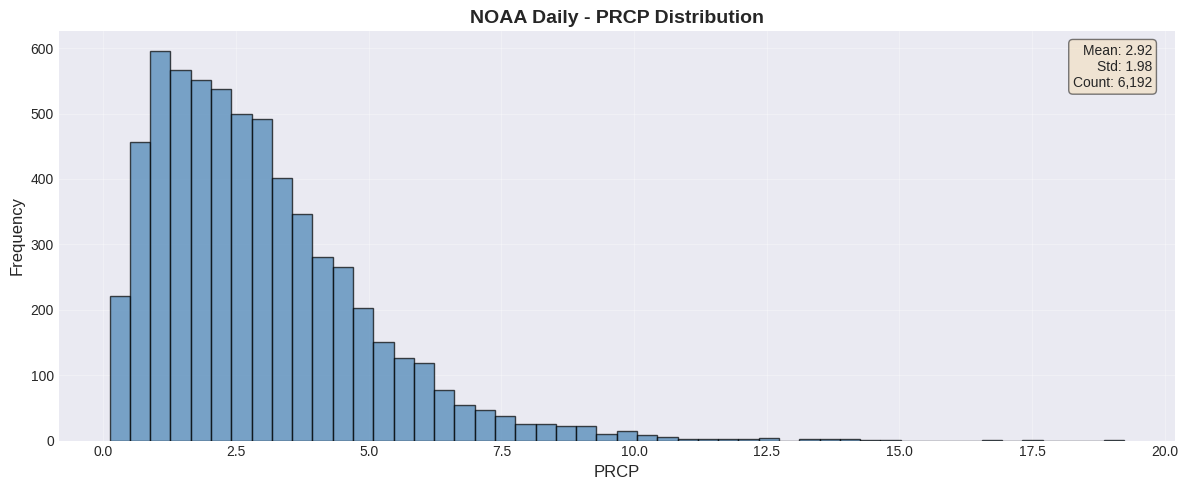

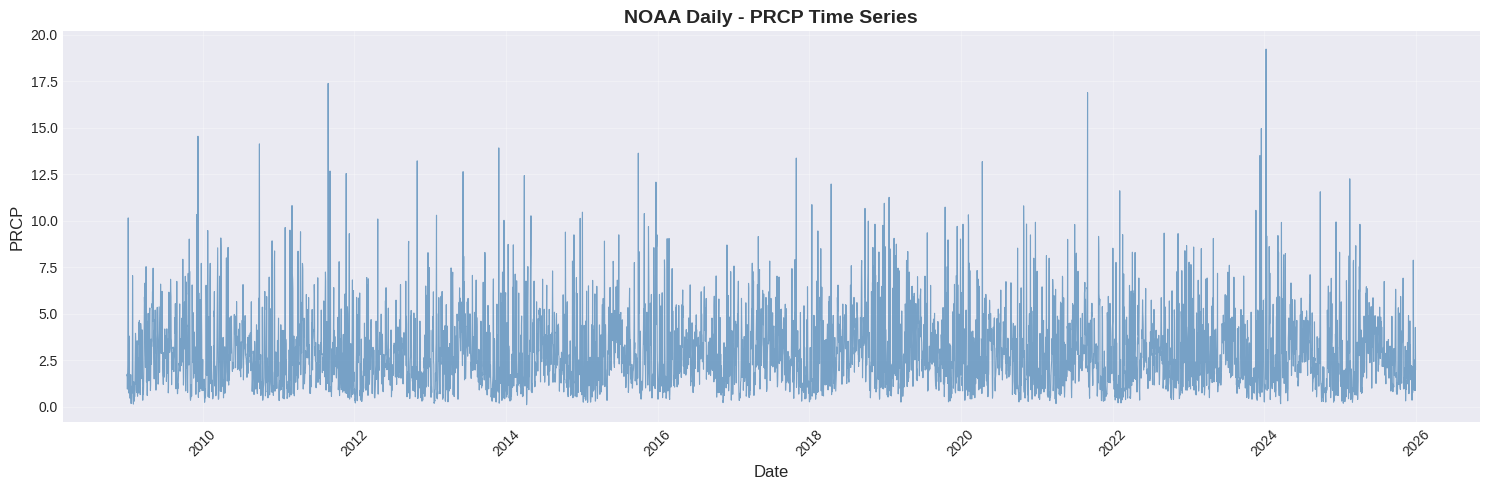

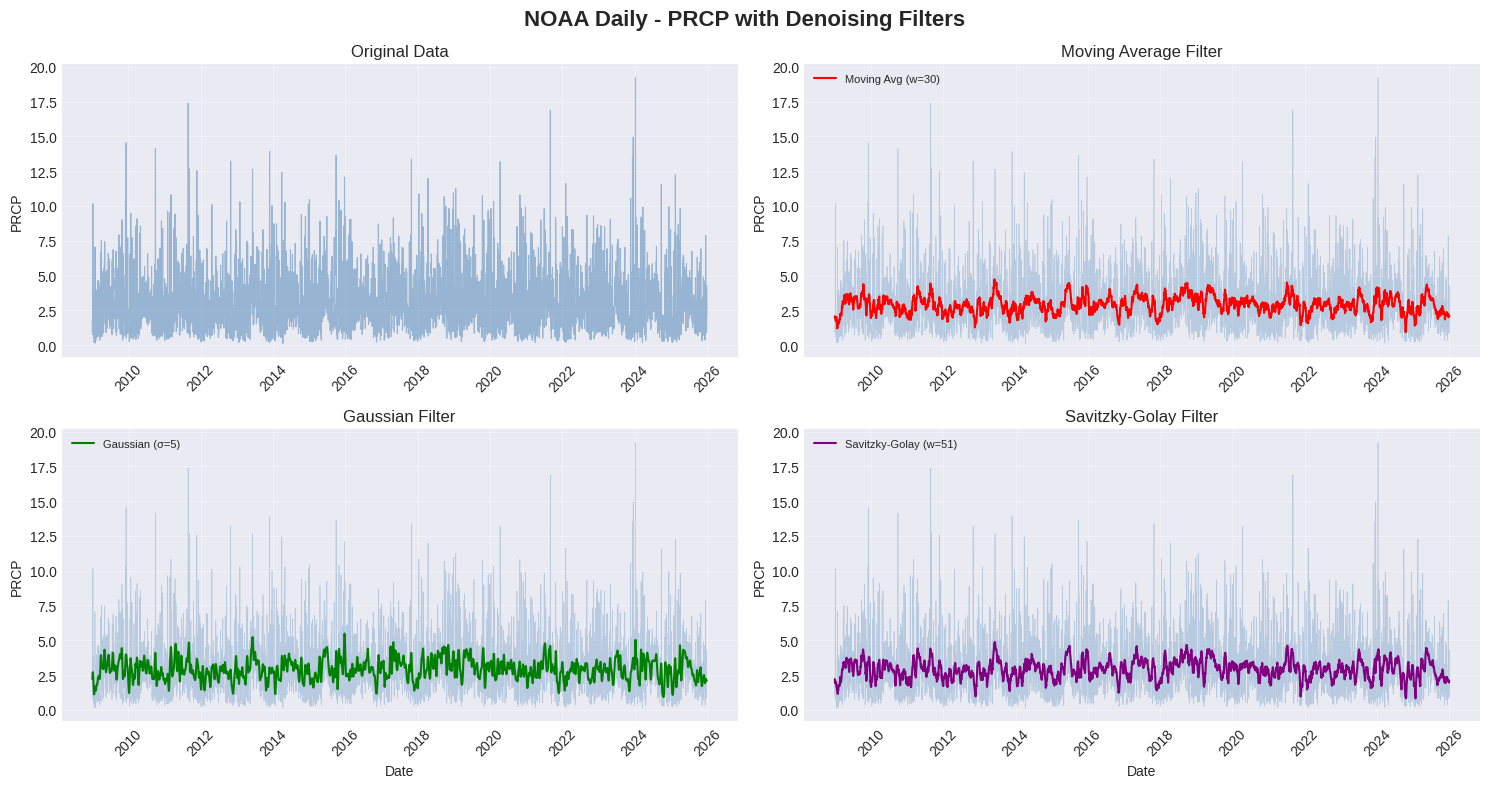

In [8]:
analyze_feature(df_daily_agg, 'date', 'PRCP', 'NOAA Daily', apply_denoising=True)

## Feature Analysis: TMAX (Maximum Temperature)


Analyzing: TMAX from NOAA Daily



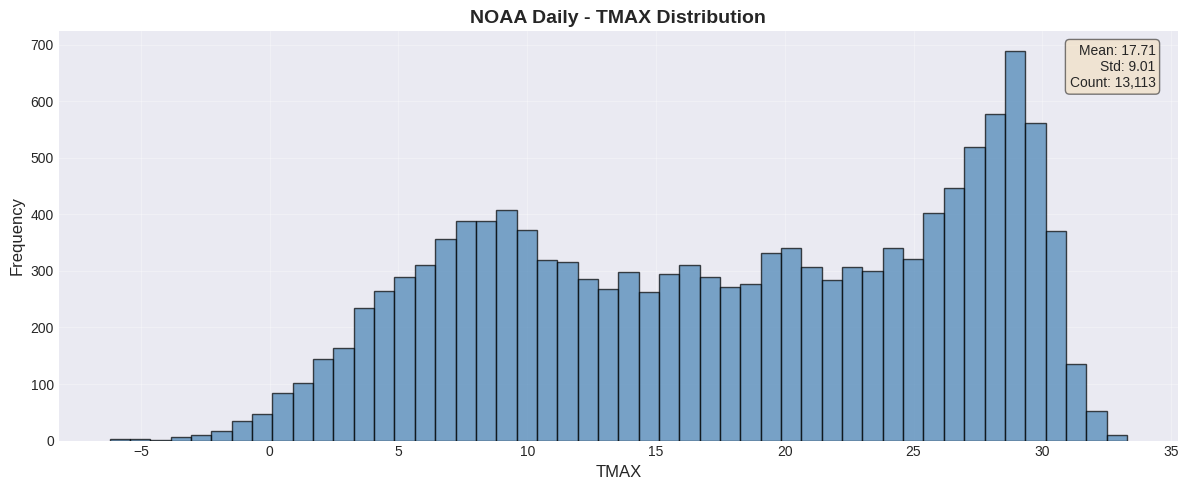

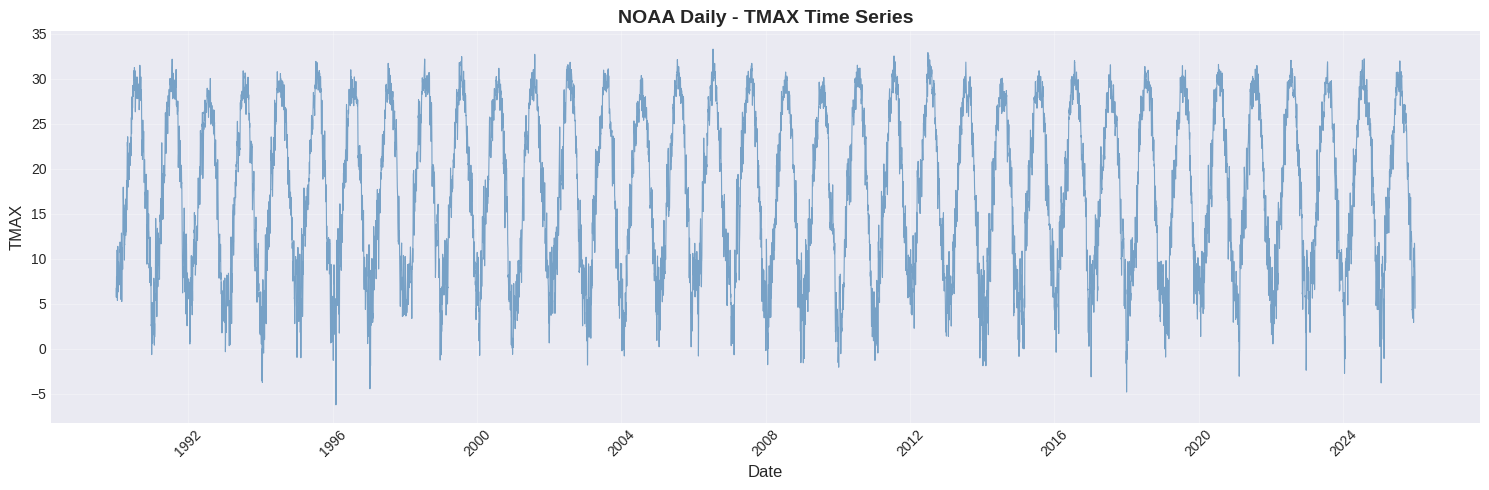

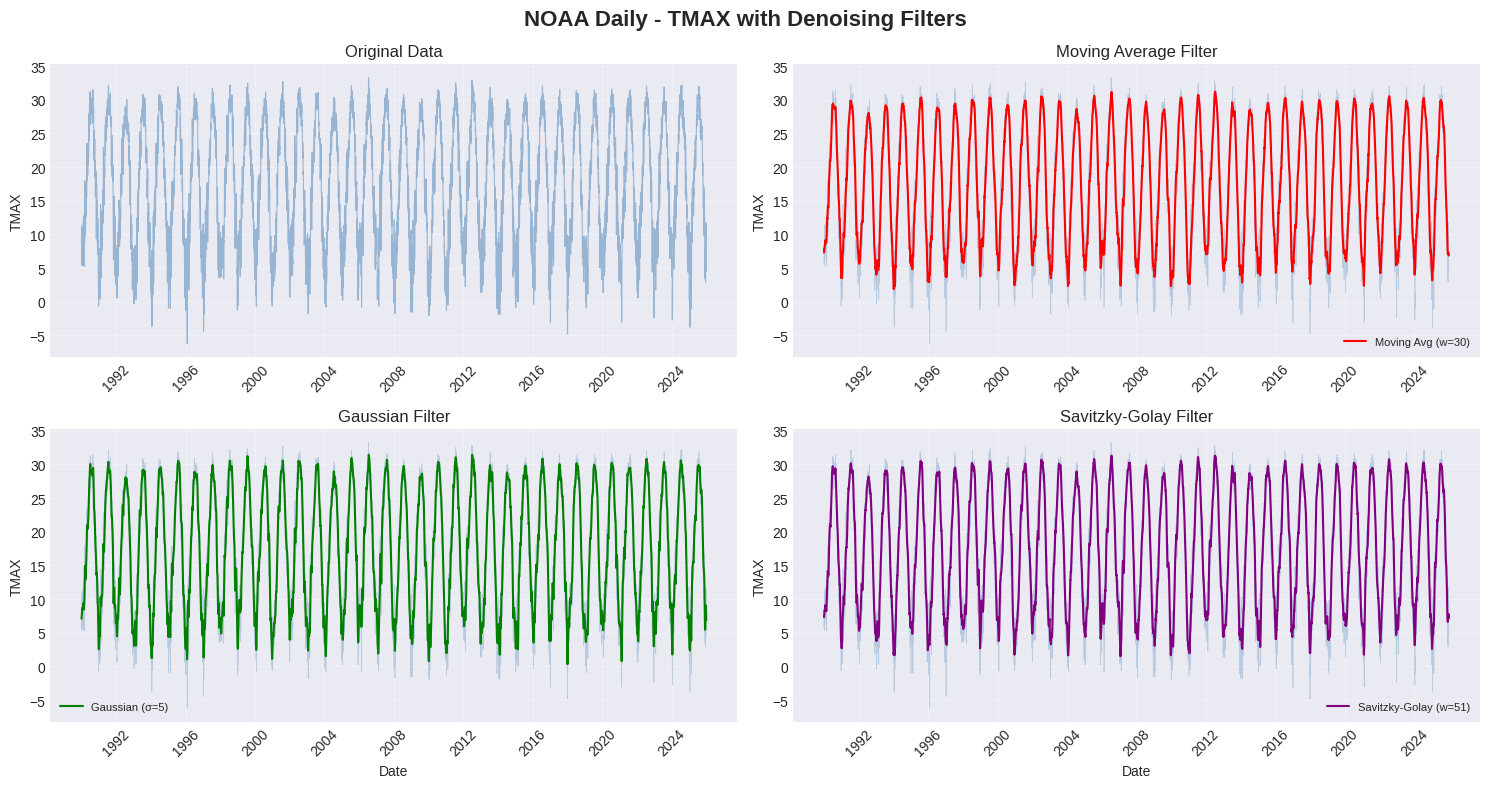

In [9]:
analyze_feature(df_daily_agg, 'date', 'TMAX', 'NOAA Daily', apply_denoising=True)

## Feature Analysis: TMIN (Minimum Temperature)


Analyzing: TMIN from NOAA Daily



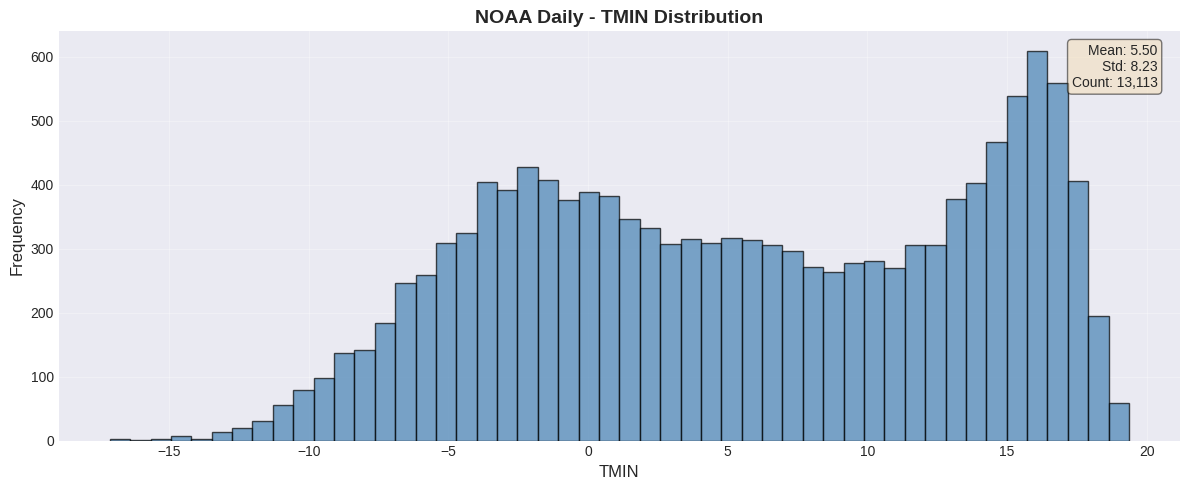

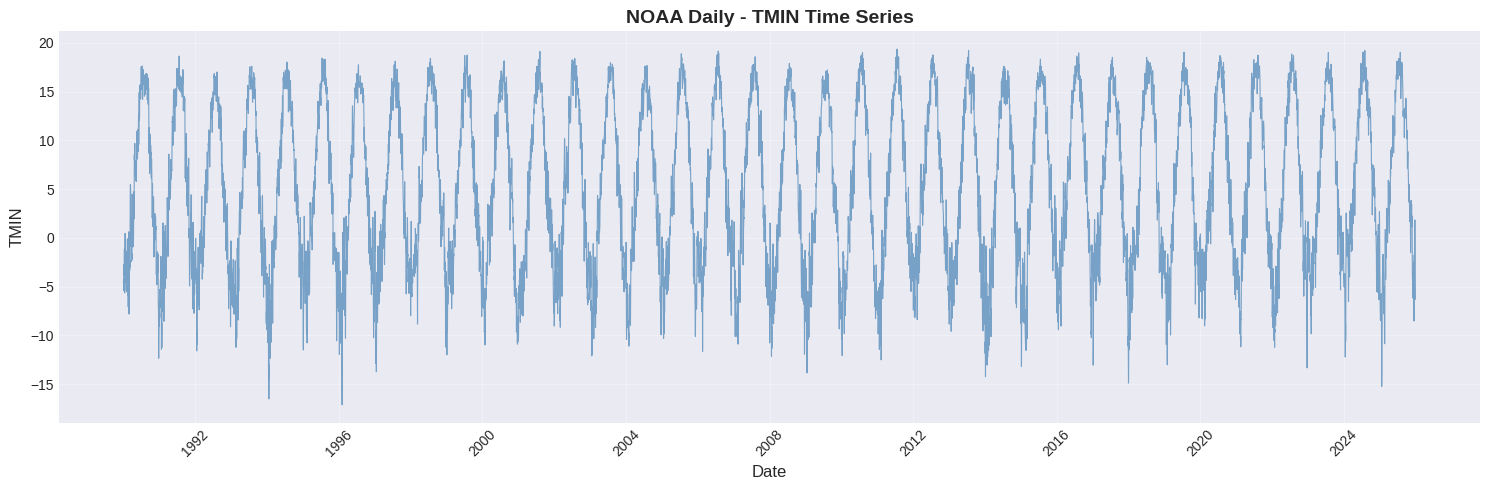

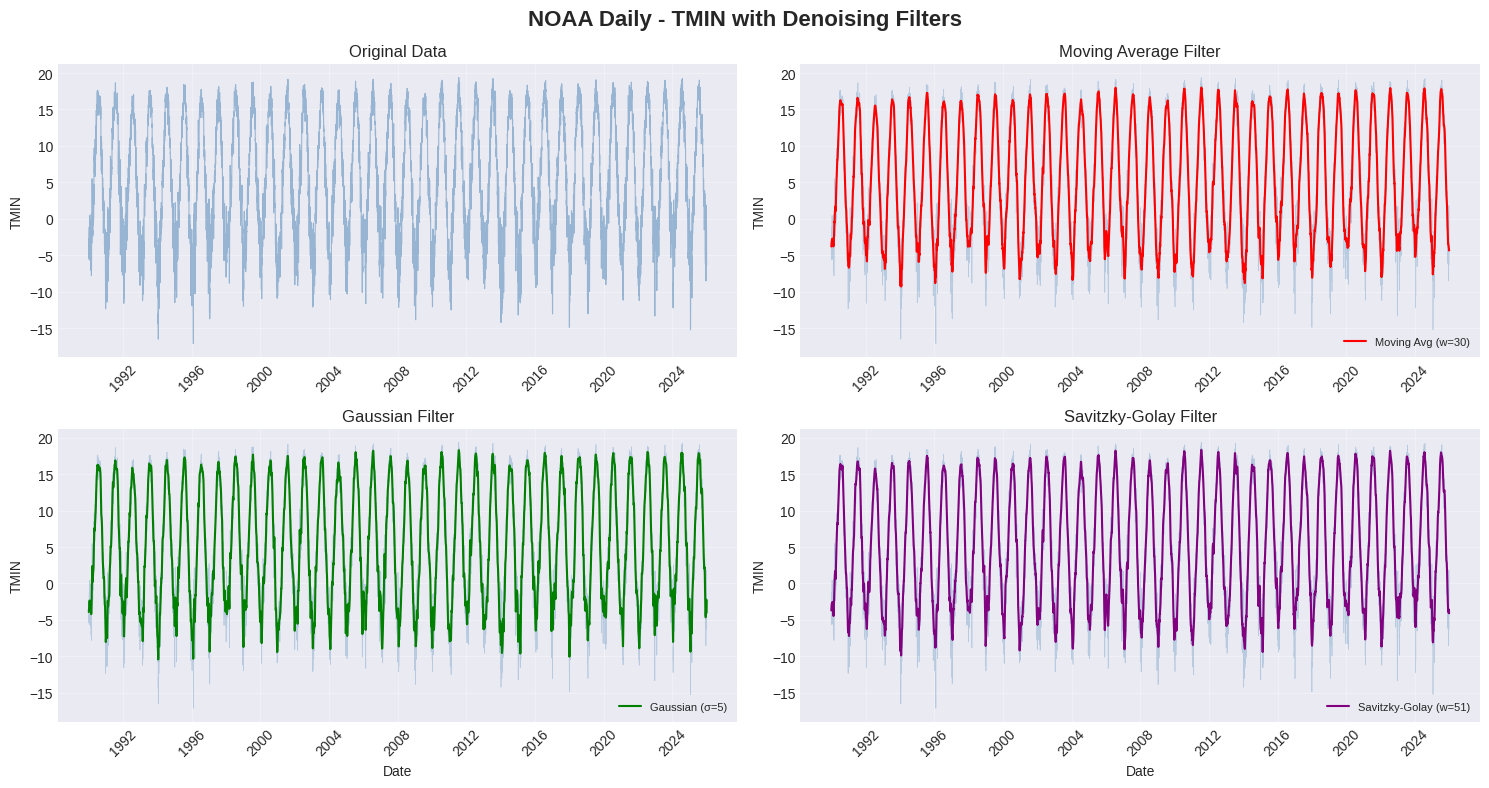

In [10]:
analyze_feature(df_daily_agg, 'date', 'TMIN', 'NOAA Daily', apply_denoising=True)

## Feature Analysis: AWND (Average Wind Speed)


Analyzing: AWND from NOAA Daily



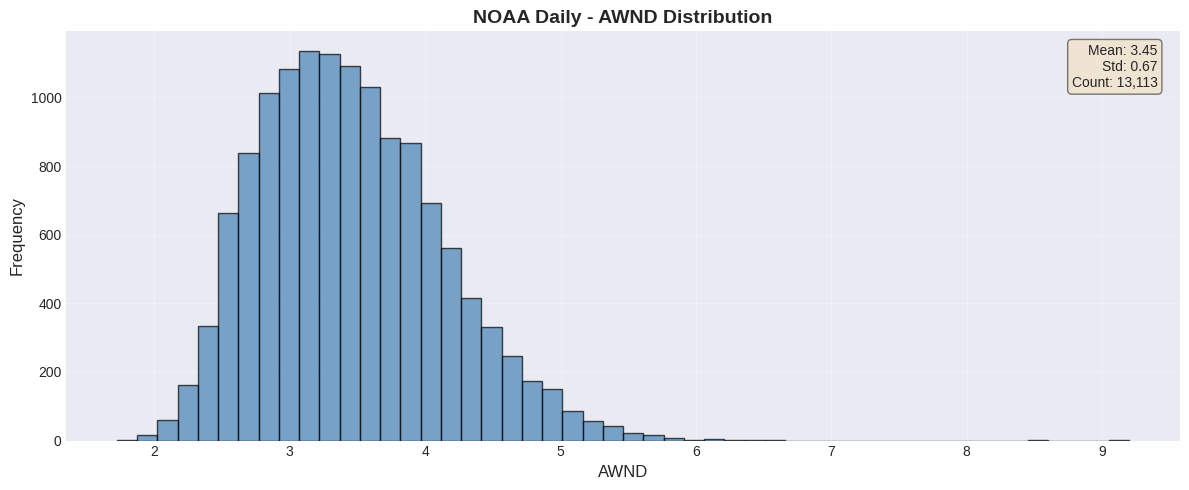

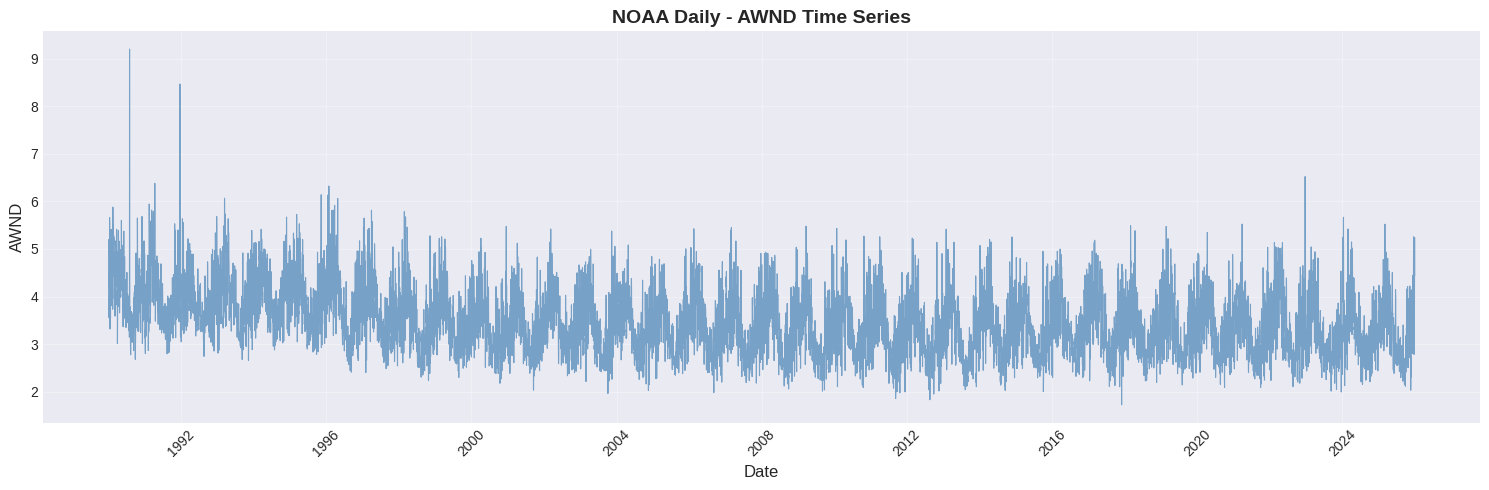

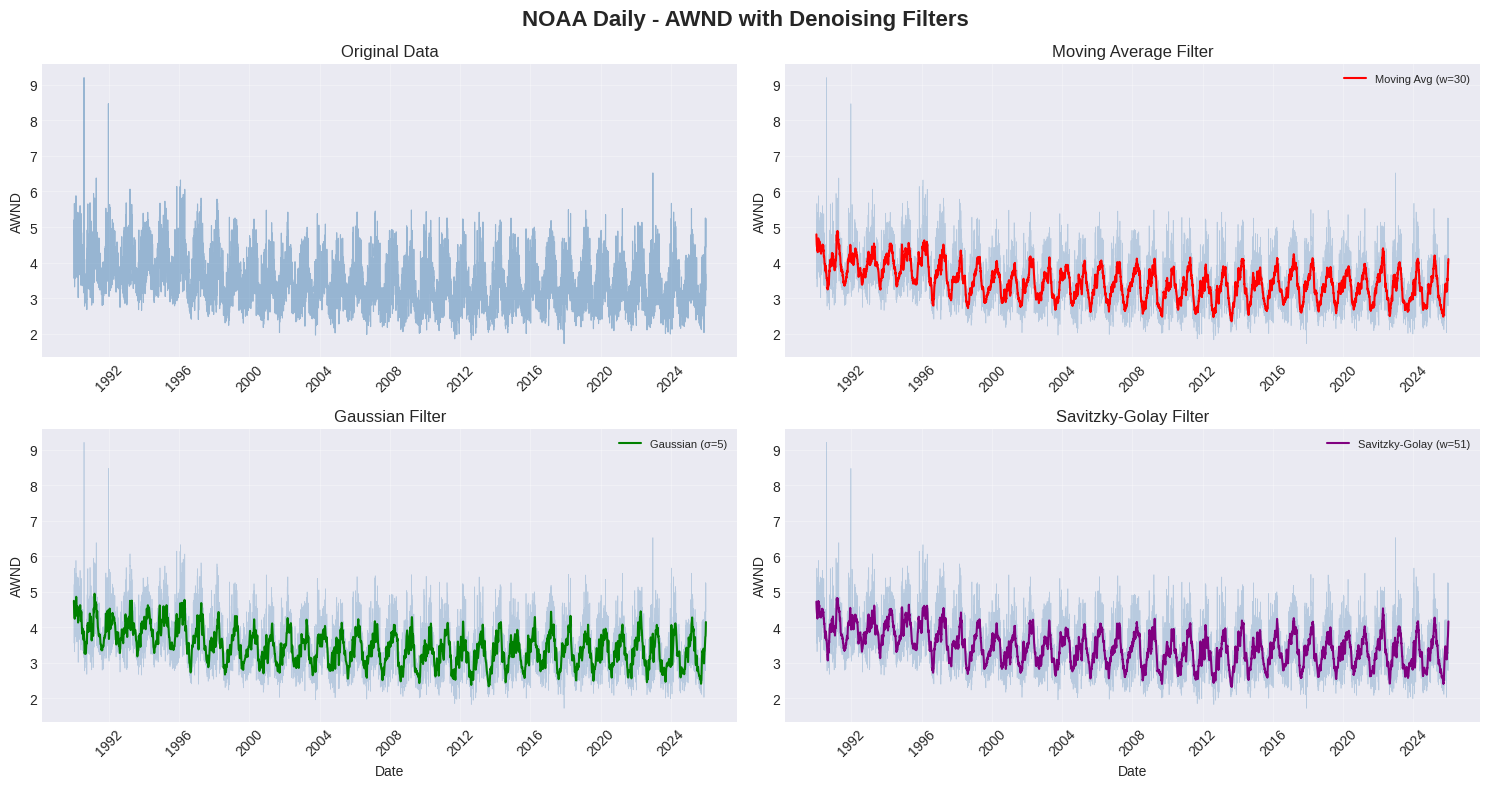

In [11]:
analyze_feature(df_daily_agg, 'date', 'AWND', 'NOAA Daily', apply_denoising=True)

---
# NOAA Weekly Weather Data Analysis

## Load Data

In [12]:
print("Loading NOAA Weekly data...")
df_weekly = pd.read_csv(PATH_NOAA_WEEKLY)
df_weekly['date'] = pd.to_datetime(df_weekly['date'])
print(f"Shape: {df_weekly.shape}")
print(f"\nColumns: {df_weekly.columns.tolist()}")
print(f"\nDate range: {df_weekly['date'].min()} to {df_weekly['date'].max()}")
print(f"\nFirst few rows:")
df_weekly.head()

Loading NOAA Weekly data...
Shape: (94000, 6)

Columns: ['state', 'date', 'PRCP', 'TMAX', 'TMIN', 'AWND']

Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00

First few rows:


,state,date,PRCP,TMAX,TMIN,AWND
0,AK,1990-01-01,NaN,-11.266597,-18.090278,4.023571
1,AK,1990-01-08,NaN,-8.162190,-17.025771,4.218299
2,AK,1990-01-15,NaN,-1.904951,-8.212460,4.729286
3,AK,1990-01-22,NaN,-10.639633,-18.063999,3.094218
4,AK,1990-01-29,NaN,-15.823874,-24.261170,4.513831


## Data Summary

In [14]:
df_weekly.describe()

,date,PRCP,TMAX,TMIN,AWND
count,94000,44400.000000,94000.000000,94000.000000,93999.000000
mean,2007-12-31 04:38:48.510638336,20.349699,17.666079,5.465153,3.452333
min,1990-01-01 00:00:00,0.000000,-24.336881,-34.482580,0.616667
25%,1999-01-02 06:00:00,5.193384,9.633348,-1.623742,2.702381
50%,2008-01-03 12:00:00,14.552650,19.101222,5.697199,3.341071
75%,2016-12-27 18:00:00,29.269063,26.558311,13.583924,4.080945
max,2025-12-29 00:00:00,240.908633,41.949391,26.381025,45.108571
std,NaN,20.437725,10.608269,9.882602,1.092488


In [15]:
print("Missing values per column:")
df_weekly.isnull().sum()

Missing values per column:


state        0
date         0
PRCP     49600
TMAX         0
TMIN         0
AWND         1
dtype: int64

## Aggregate Weekly Data by Date

In [16]:
df_weekly_agg = df_weekly.groupby('date').agg({'PRCP': 'mean', 'TMAX': 'mean', 'TMIN': 'mean', 'AWND': 'mean'}).reset_index()
print(f"Aggregated shape: {df_weekly_agg.shape}")
df_weekly_agg.head()

Aggregated shape: (1879, 5)


,date,PRCP,TMAX,TMIN,AWND
0,1990-01-01,NaN,7.051981,-3.862139,4.209915
1,1990-01-08,NaN,8.559069,-2.900961,4.719708
2,1990-01-15,NaN,9.050974,-1.562375,3.908892
3,1990-01-22,NaN,8.838162,-3.003364,4.712054
4,1990-01-29,NaN,8.031889,-3.547308,4.398213


## Feature Analysis: PRCP (Precipitation)


Analyzing: PRCP from NOAA Weekly



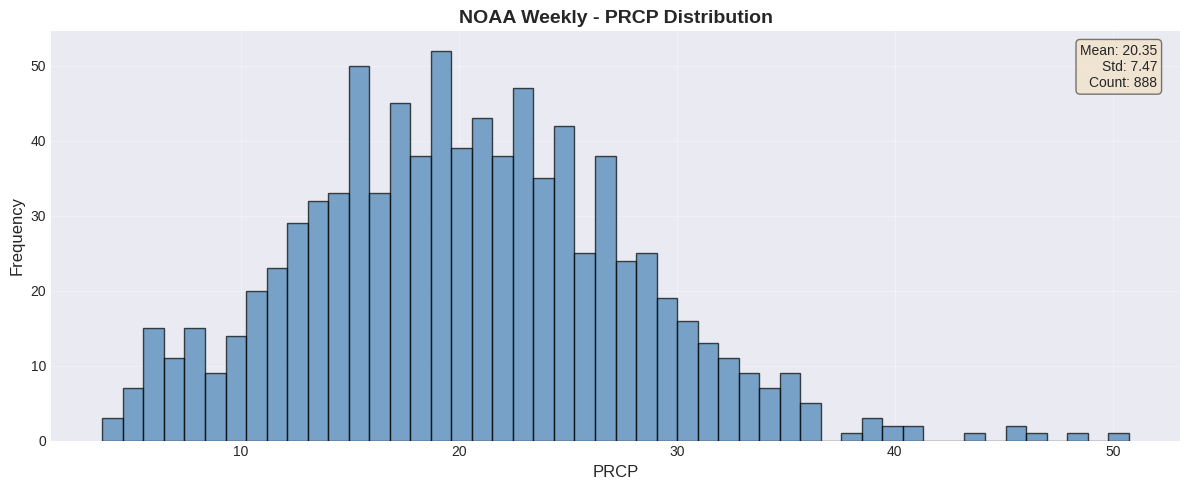

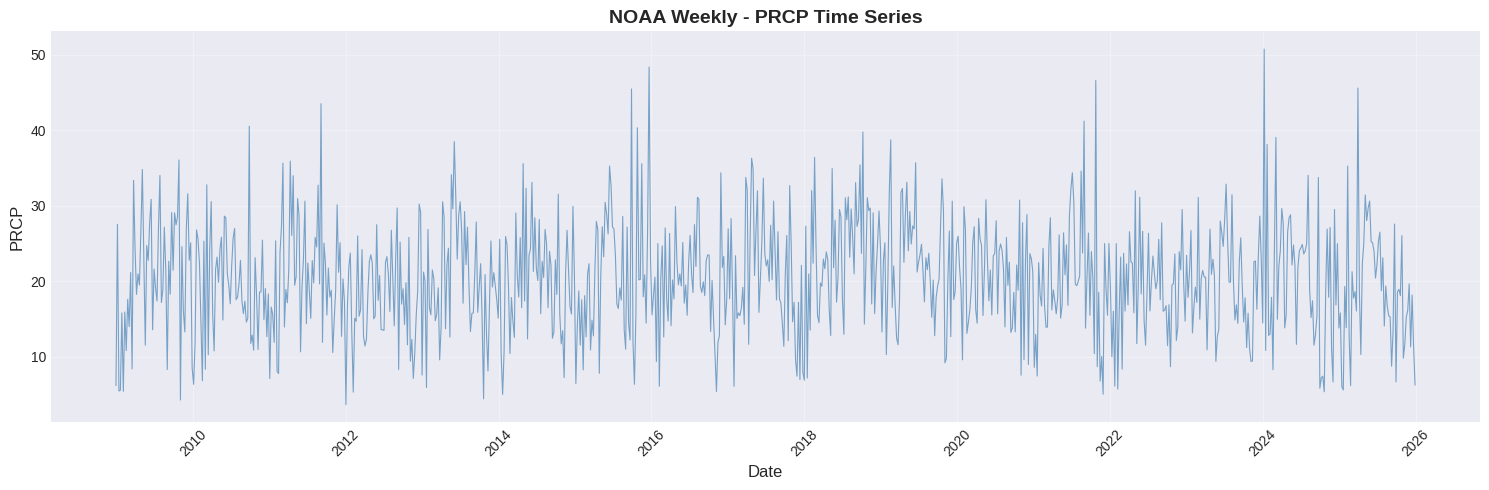

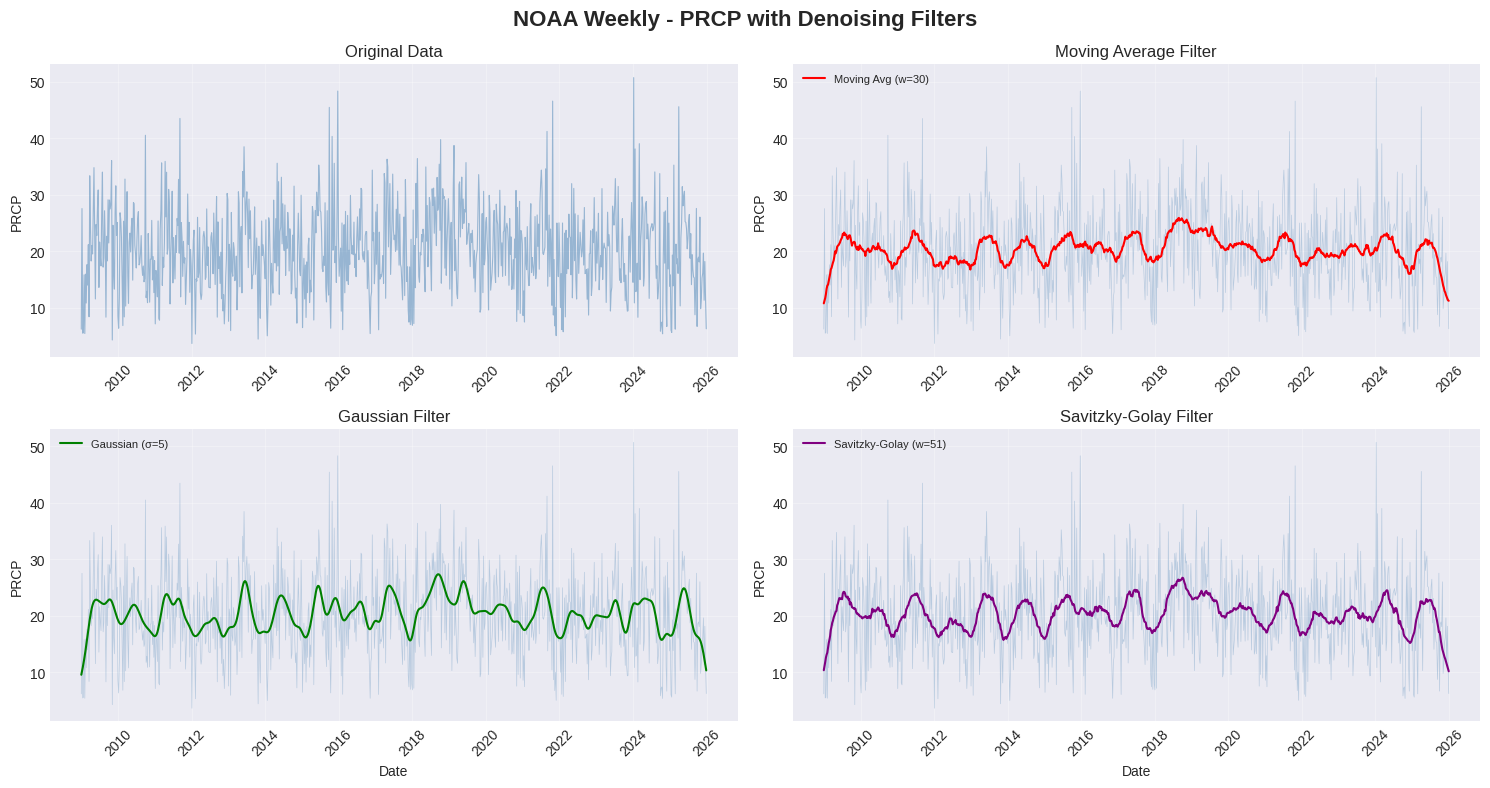

In [17]:
analyze_feature(df_weekly_agg, 'date', 'PRCP', 'NOAA Weekly', apply_denoising=True)

## Feature Analysis: TMAX (Maximum Temperature)


Analyzing: TMAX from NOAA Weekly



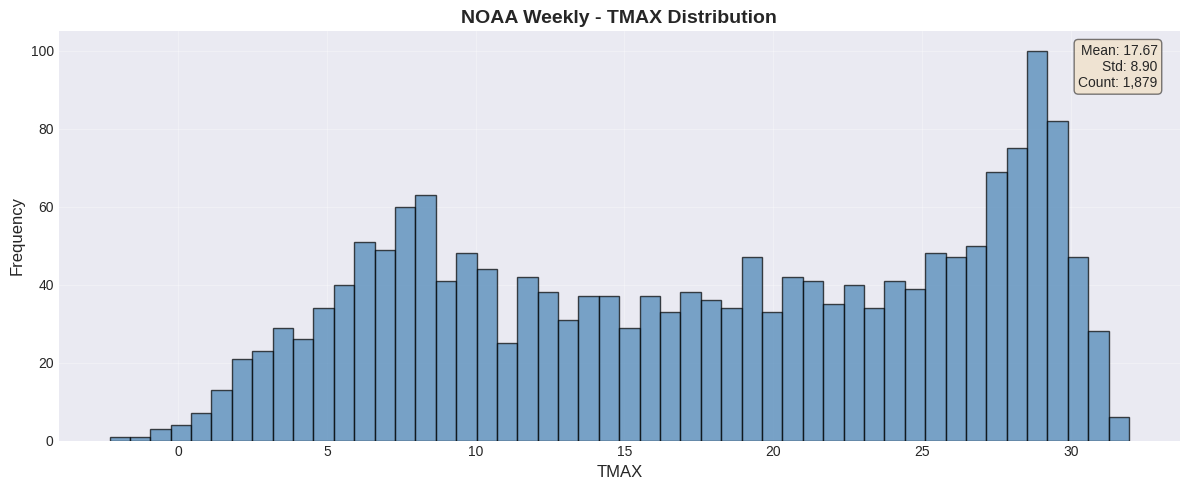

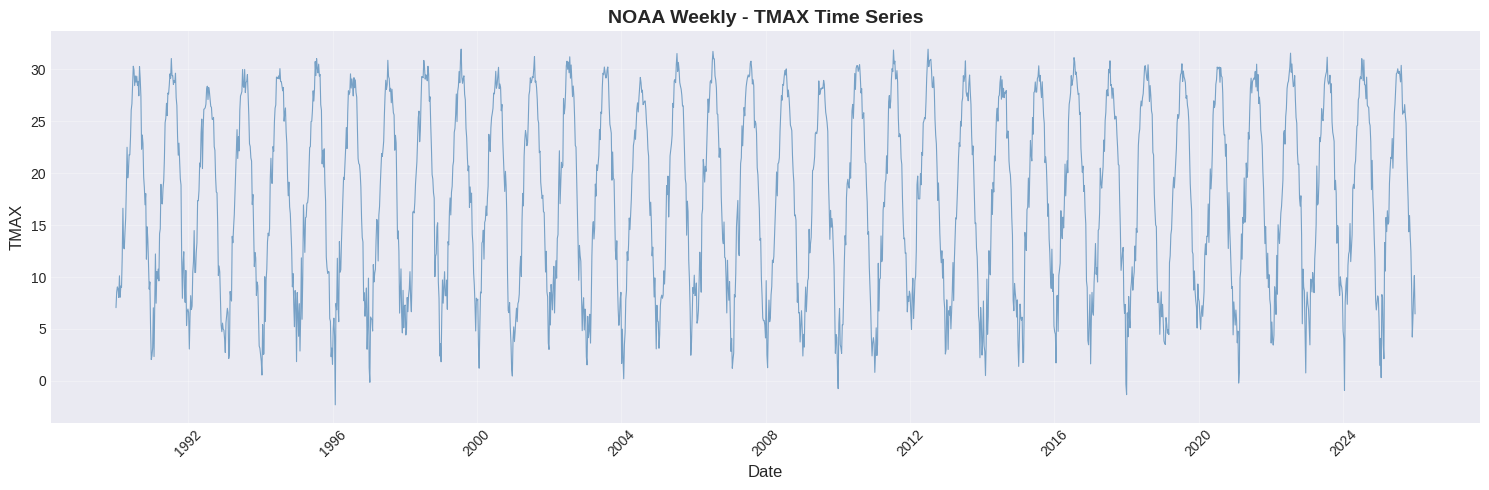

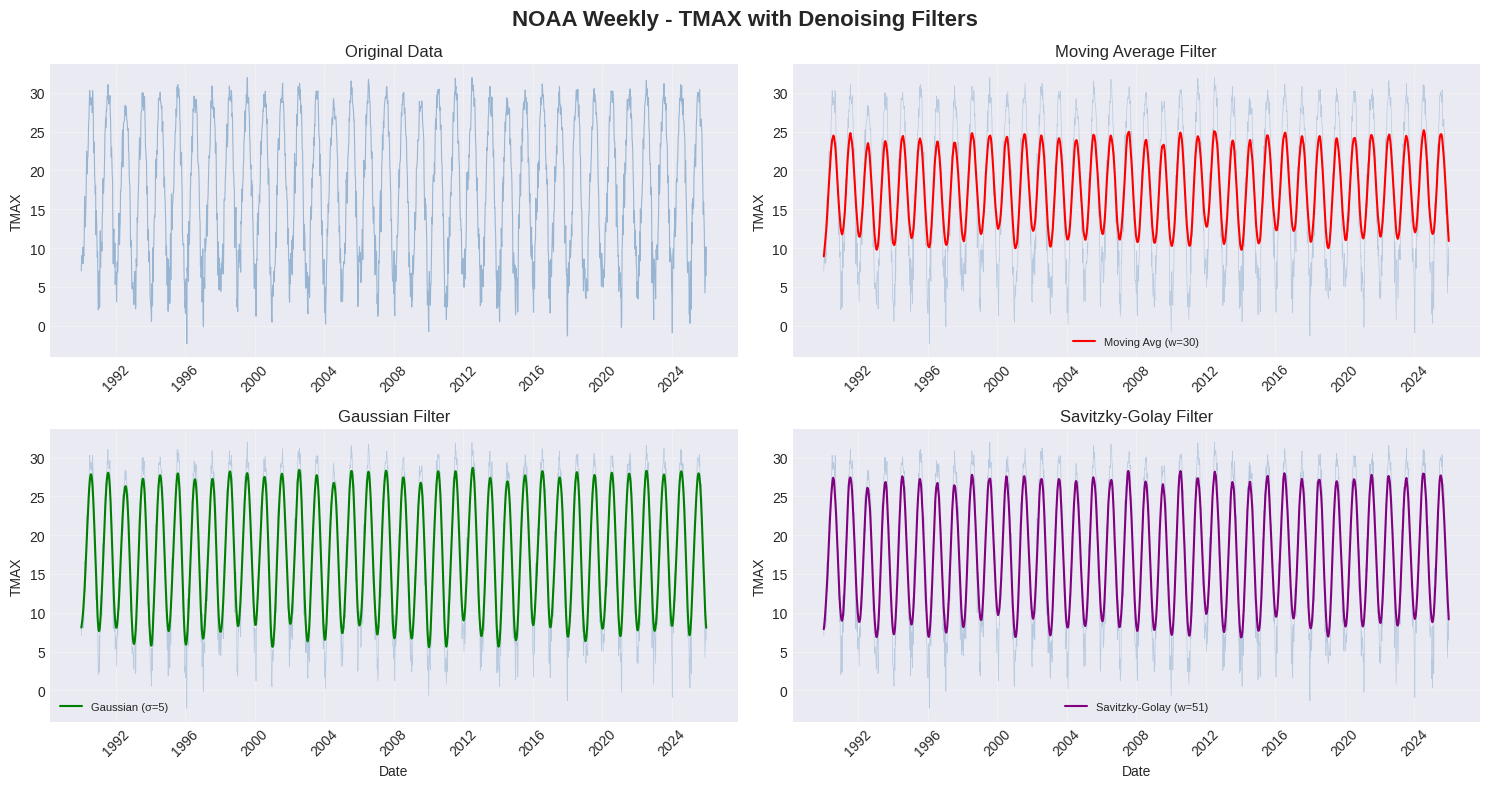

In [18]:
analyze_feature(df_weekly_agg, 'date', 'TMAX', 'NOAA Weekly', apply_denoising=True)

## Feature Analysis: TMIN (Minimum Temperature)


Analyzing: TMIN from NOAA Weekly



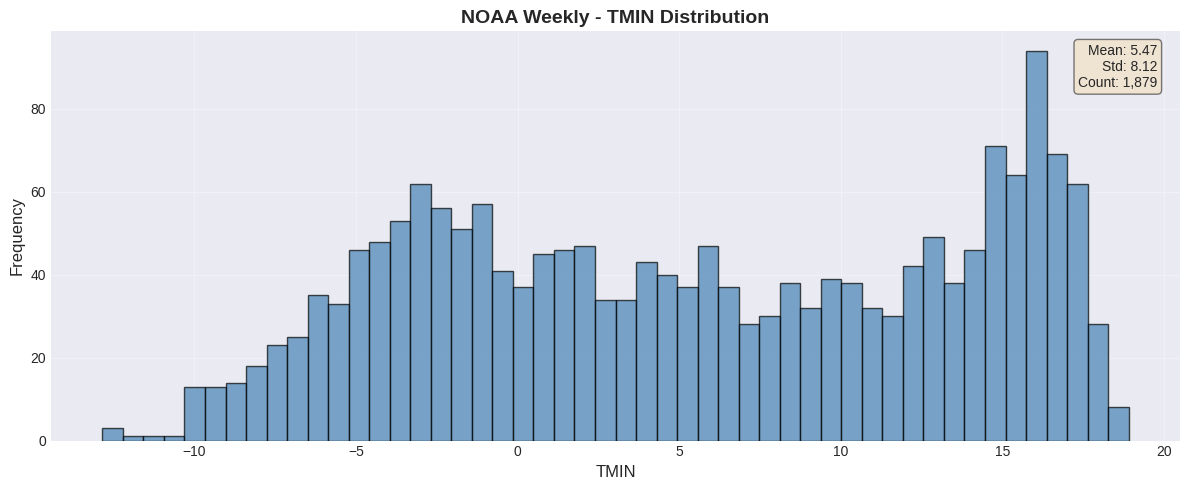

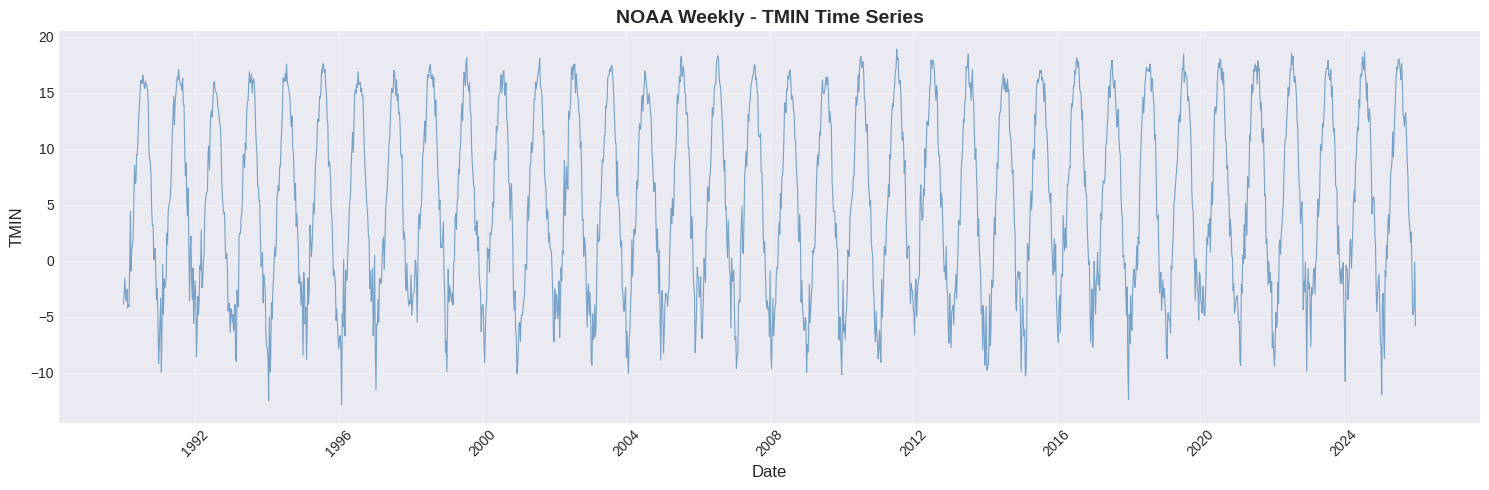

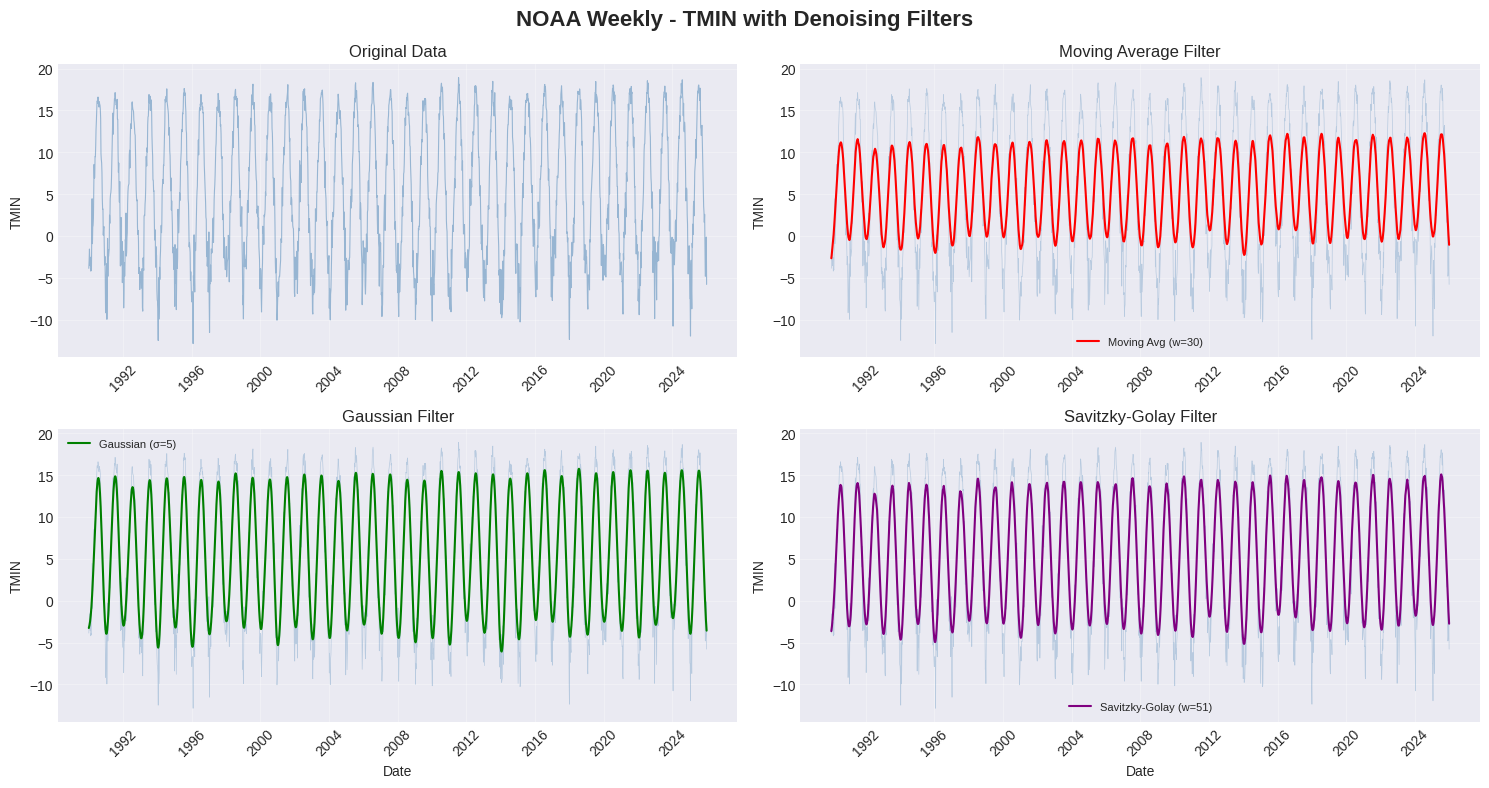

In [19]:
analyze_feature(df_weekly_agg, 'date', 'TMIN', 'NOAA Weekly', apply_denoising=True)

## Feature Analysis: AWND (Average Wind Speed)


Analyzing: AWND from NOAA Weekly



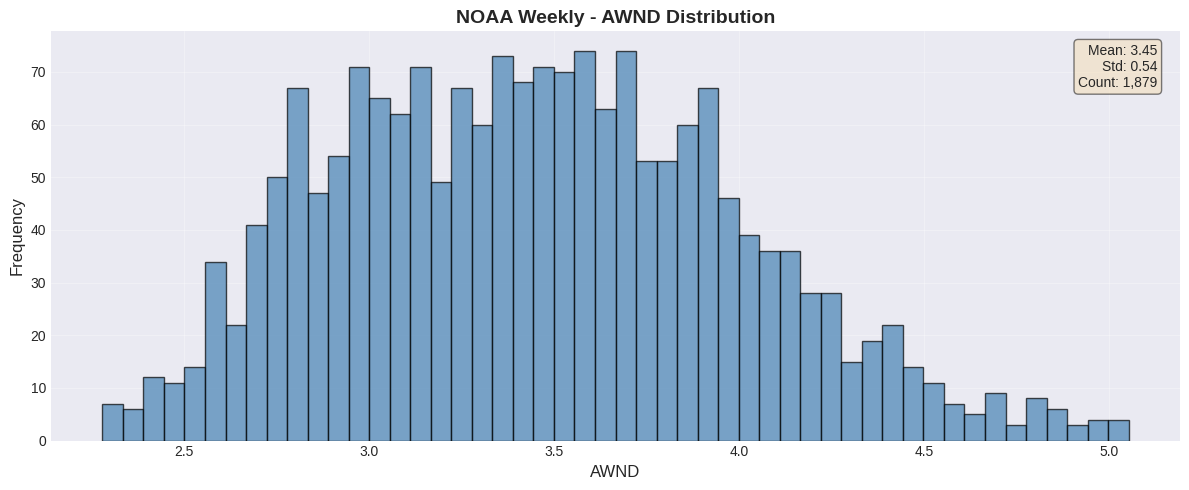

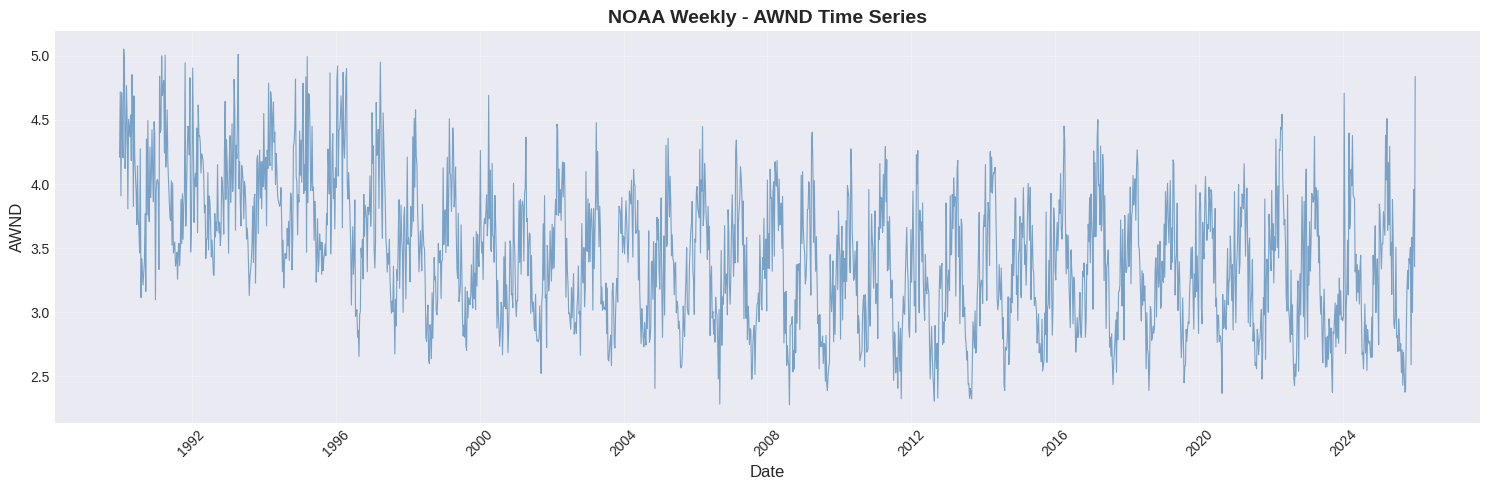

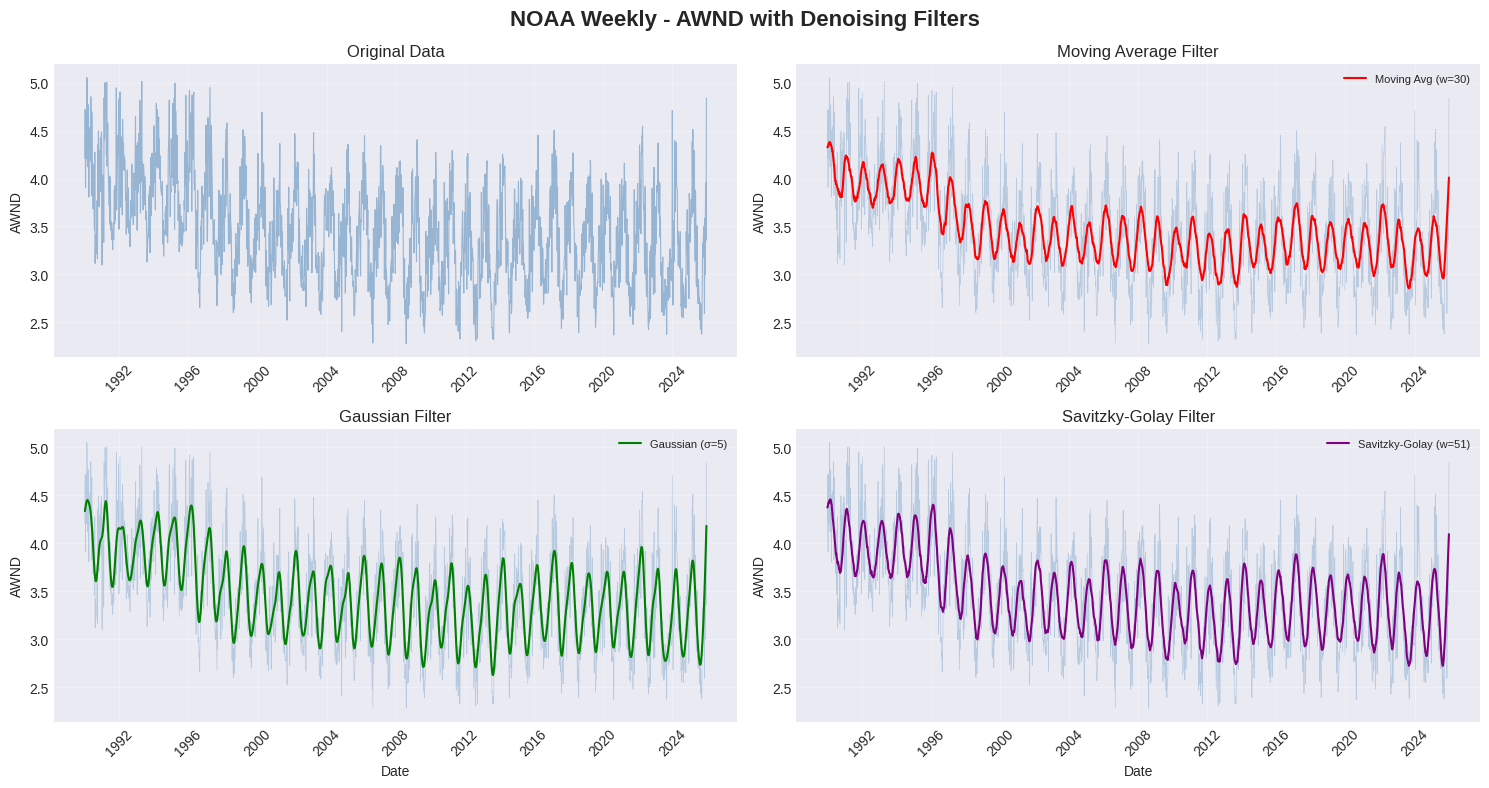

In [20]:
analyze_feature(df_weekly_agg, 'date', 'AWND', 'NOAA Weekly', apply_denoising=True)

---
# CO2 Mole Fraction Weekly Data Analysis

## Load Data

In [21]:
print("Loading CO2 Weekly data...")
df_co2 = pd.read_csv(PATH_CO2_WEEKLY)
df_co2['date'] = pd.to_datetime(df_co2['date'])
print(f"Shape: {df_co2.shape}")
print(f"\nColumns: {df_co2.columns.tolist()}")
print(f"\nDate range: {df_co2['date'].min()} to {df_co2['date'].max()}")
print(f"\nFirst few rows:")
df_co2.head()

Loading CO2 Weekly data...
Shape: (886, 3)

Columns: ['Unnamed: 0', 'date', 'co2_molfrac_ppm']

Date range: 2008-12-29 00:00:00 to 2025-12-22 00:00:00

First few rows:


,Unnamed: 0,date,co2_molfrac_ppm
0,0,2008-12-29,386.63
1,1,2009-01-05,387.24
2,2,2009-01-12,387.37
3,3,2009-01-19,387.74
4,4,2009-01-26,387.25


## Data Summary

In [22]:
df_co2.describe()

,Unnamed: 0,date,co2_molfrac_ppm
count,886.000000,886,886.000000
mean,442.500000,2017-06-22 14:27:54.040632064,406.700102
min,0.000000,2008-12-29 00:00:00,384.080000
25%,221.250000,2013-03-26 18:00:00,395.877500
50%,442.500000,2017-06-22 12:00:00,406.830000
75%,663.750000,2021-09-18 06:00:00,417.077500
max,885.000000,2025-12-22 00:00:00,430.860000
std,255.910466,NaN,12.253353


In [23]:
print("Missing values per column:")
df_co2.isnull().sum()

Missing values per column:


Unnamed: 0         0
date               0
co2_molfrac_ppm    0
dtype: int64

## Feature Analysis: CO2 Mole Fraction (ppm)


Analyzing: co2_molfrac_ppm from CO2 Weekly (Mauna Loa)



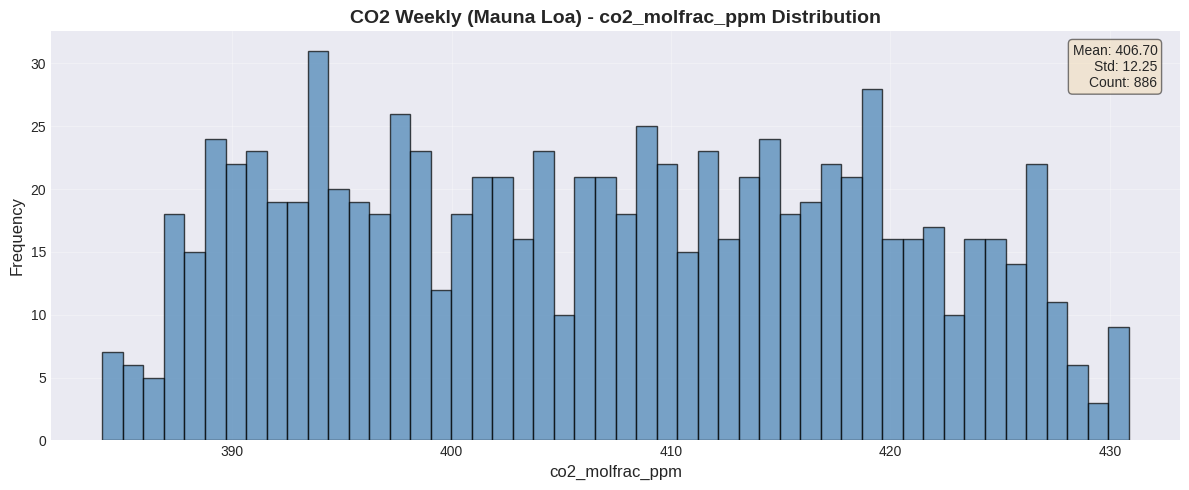

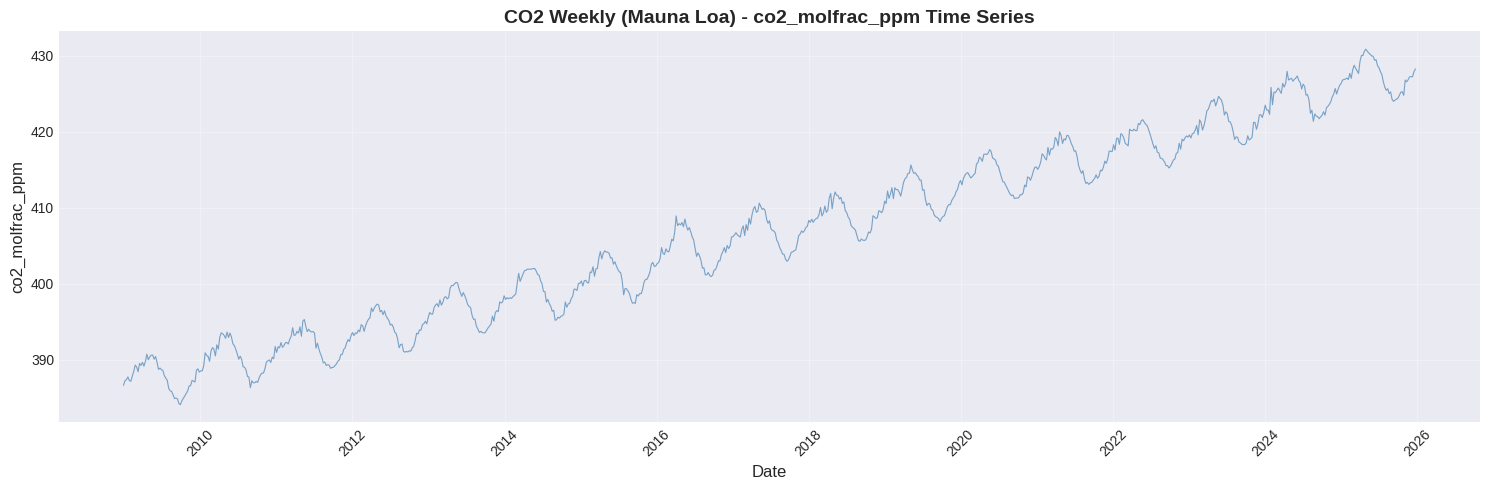

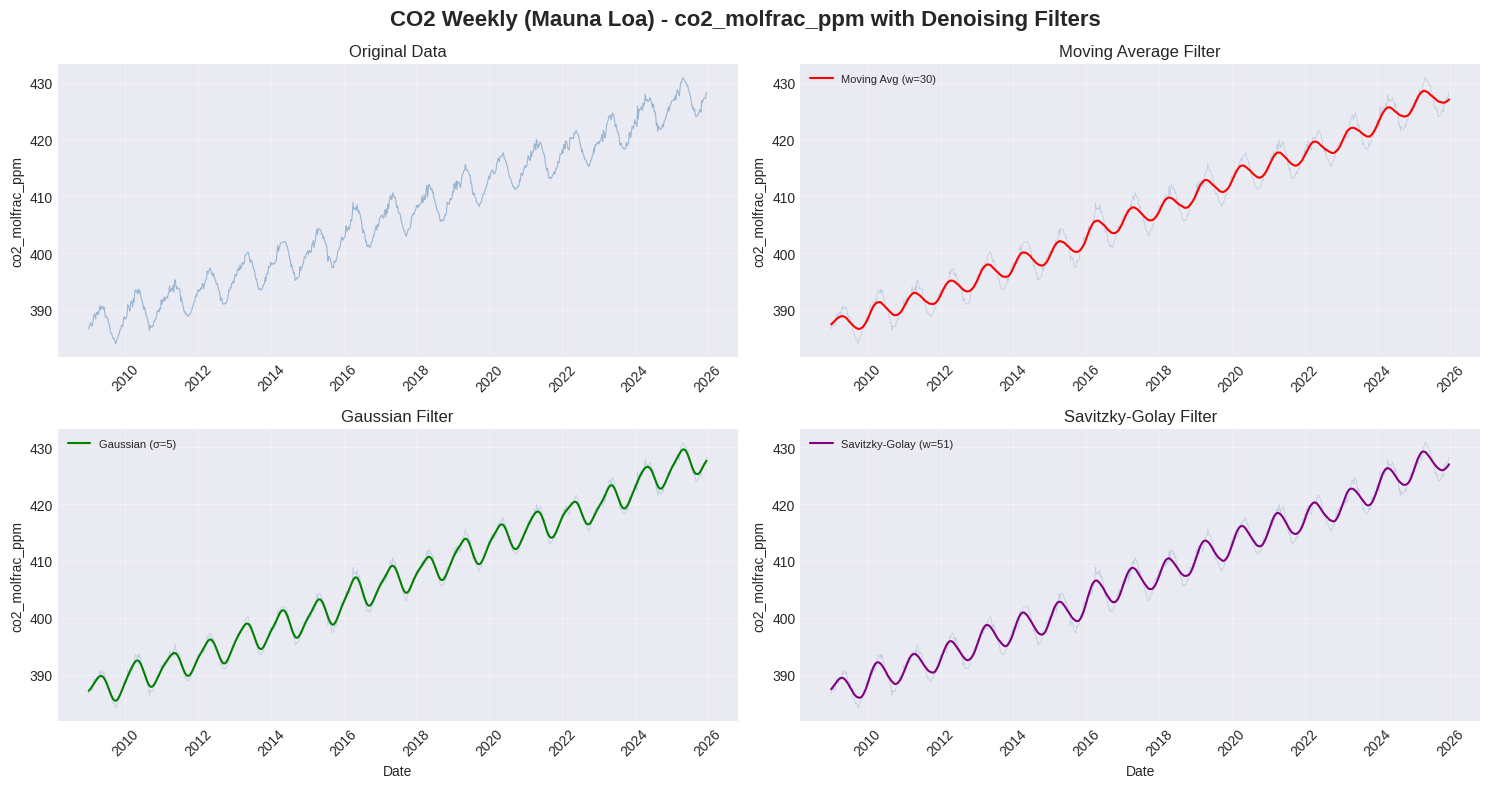

In [24]:
analyze_feature(df_co2, 'date', 'co2_molfrac_ppm', 'CO2 Weekly (Mauna Loa)', apply_denoising=True)

---
# SPI (Standardized Precipitation Index) Weekly Data Analysis

## Load Data

In [ ]:
print("Loading SPI Weekly data...")
df_spi = pd.read_csv(PATH_SPI_WEEKLY)
df_spi['date'] = pd.to_datetime(df_spi['date'])
df_spi['week_date'] = pd.to_datetime(df_spi['week_date'])
print(f"Shape: {df_spi.shape}")
print(f"\nColumns: {df_spi.columns.tolist()}")
print(f"\nDate range: {df_spi['date'].min()} to {df_spi['date'].max()}")
print(f"\nStates: {df_spi['state'].nunique()} unique")
print(f"\nFirst few rows:")
df_spi.head()

## Data Summary

In [ ]:
df_spi.describe()

In [ ]:
print("Missing values per column:")
df_spi.isnull().sum()

## Aggregate SPI Data by Date

In [ ]:
spi_features = ['SPI_7d', 'SPI_1m', 'SPI_2m', 'SPI_3m', 'SPI_6m', 'SPI_12m']
df_spi_agg = df_spi.groupby('date')[spi_features].mean().reset_index()
print(f"Aggregated shape: {df_spi_agg.shape}")
df_spi_agg.head()

## Feature Analysis: SPI_7d (7-Day SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_7d', 'SPI Weekly', apply_denoising=True)

## Feature Analysis: SPI_1m (1-Month SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_1m', 'SPI Weekly', apply_denoising=True)

## Feature Analysis: SPI_2m (2-Month SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_2m', 'SPI Weekly', apply_denoising=True)

## Feature Analysis: SPI_3m (3-Month SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_3m', 'SPI Weekly', apply_denoising=True)

## Feature Analysis: SPI_6m (6-Month SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_6m', 'SPI Weekly', apply_denoising=True)

## Feature Analysis: SPI_12m (12-Month SPI)

In [ ]:
analyze_feature(df_spi_agg, 'date', 'SPI_12m', 'SPI Weekly', apply_denoising=True)

---
# PDSI (Palmer Drought Severity Index) Weekly Data Analysis

## Load and Combine Data

Palmer data is stored per climate division. We load all divisions and combine into a single DataFrame.

In [ ]:
print("Loading Palmer (PDSI) data from all climate divisions...")

palmer_records = []
palmer_files = sorted(glob.glob(os.path.join(PATH_PALMER, '*', '*.csv')))

for filepath in palmer_files:
    division_id = os.path.splitext(os.path.basename(filepath))[0]
    state_dir = os.path.basename(os.path.dirname(filepath))
    state_name = '_'.join(state_dir.split('_')[1:])
    
    with open(filepath, 'r') as f:
        header_line = f.readline().strip()
    
    df_div = pd.read_csv(filepath, skiprows=1, header=None, names=['date_raw', 'pdsi'])
    df_div['date'] = pd.to_datetime(df_div['date_raw'], format='%Y%m%d')
    df_div['division_id'] = division_id
    df_div['state'] = state_name
    df_div = df_div[['date', 'state', 'division_id', 'pdsi']]
    palmer_records.append(df_div)

df_pdsi = pd.concat(palmer_records, ignore_index=True)
print(f"Total shape: {df_pdsi.shape}")
print(f"States: {df_pdsi['state'].nunique()} unique")
print(f"Divisions: {df_pdsi['division_id'].nunique()} unique")
print(f"Date range: {df_pdsi['date'].min()} to {df_pdsi['date'].max()}")
print(f"\nFirst few rows:")
df_pdsi.head()

## Data Summary

In [ ]:
df_pdsi.describe()

In [ ]:
print("Missing values per column:")
df_pdsi.isnull().sum()

## Aggregate PDSI Data by Date

In [ ]:
df_pdsi_agg = df_pdsi.groupby('date')['pdsi'].mean().reset_index()
print(f"Aggregated shape: {df_pdsi_agg.shape}")
df_pdsi_agg.head()

## Feature Analysis: PDSI (Palmer Drought Severity Index)

In [ ]:
analyze_feature(df_pdsi_agg, 'date', 'pdsi', 'PDSI Weekly (Palmer)', apply_denoising=True)

---
# Summary and Conclusions

## Key Observations

This notebook analyzed climate data from five sources:

1. **NOAA Daily Data**: High-frequency weather measurements (PRCP, TMAX, TMIN, AWND)
2. **NOAA Weekly Data**: Aggregated weekly weather measurements
3. **CO2 Weekly Data**: Atmospheric CO2 concentrations from Mauna Loa Observatory
4. **SPI Weekly Data**: Standardized Precipitation Index at multiple timescales (7d, 1m, 2m, 3m, 6m, 12m)
5. **PDSI Weekly Data**: Palmer Drought Severity Index across U.S. climate divisions

### Denoising Methods Applied:

- **Moving Average**: Simple uniform filter for smoothing
- **Gaussian Filter**: Weighted smoothing with Gaussian kernel
- **Savitzky-Golay Filter**: Polynomial-based smoothing that preserves peaks

Each method has different characteristics:
- Moving average is simple but can lag behind trends
- Gaussian filter provides smooth results with good noise reduction
- Savitzky-Golay preserves features better while reducing noise